In [4]:
import numpy as np
import matplotlib.pyplot as plt
from denodas_model import unet
import torch
import torch.nn as nn
print(torch.cuda.device_count())
import os
import h5py
from scipy import signal

1


Trying Denoiser

In [19]:
# Load the .npy file
file_path = os.path.join("test_data", "11707192.npy")
data = np.load(file_path)
data = data[:1500, 100:7600]

# Convert the data to a tensor
data_tensor = torch.tensor(data, dtype=torch.float32)

print("Data shape:", data.shape)
print("Tensor shape:", data_tensor.shape)

Data shape: (1500, 7500)
Tensor shape: torch.Size([1500, 7500])


In [26]:
# Define U-Net parameters
ch_in = 1    # Number of input channels
ch0 = 16        # Initial number of feature maps
ch_max = 1024     # Maximum number of feature maps
factors = [5, 3, 2, 2]  # Downsampling factors (4 levels)

# Initialize model
# model = unet(1, 16, 1024, factors=(5, 3, 2, 2)) # From Qibin's code
model = unet(ch_in, ch0, ch_max, factors)

# Ensure model is in evaluation mode
model.eval()

# Pass the noisy seismic data through the model
output = model(data_tensor)

# Convert output back to NumPy for visualization
output_numpy = output.detach().numpy().squeeze()  # Remove batch & channel dimensions

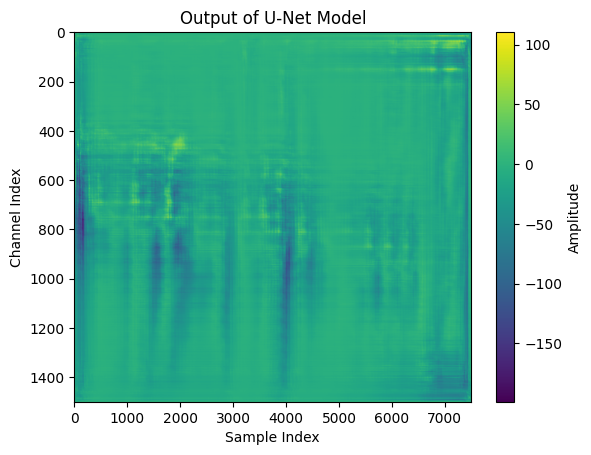

In [27]:
plt.imshow(output_numpy, aspect='auto', cmap='viridis')
plt.colorbar(label='Amplitude')
plt.xlabel('Sample Index')
plt.ylabel('Channel Index')
plt.title('Output of U-Net Model')
plt.show()

In [32]:
# Ensure the output directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Get list of files in the test_data folder
test_data_folder = "test_data"
file_list = [f for f in os.listdir(test_data_folder) if f.endswith('.npy')]

for i, file_name in enumerate(file_list):
    # Load the .npy file
    file_path = os.path.join(test_data_folder, file_name)
    data = np.load(file_path)
    data = data[:1500, 100:7600]

    # Convert the data to a tensor
    data_tensor = torch.tensor(data, dtype=torch.float32)

    # Pass the noisy seismic data through the model
    output = model(data_tensor)

    # Convert output back to NumPy for visualization
    output_numpy = output.detach().numpy().squeeze()  # Remove batch & channel dimensions

    # Plot the denoised data
    plt.imshow(output_numpy, aspect='auto', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.xlabel('Sample Index')
    plt.ylabel('Channel Index')
    plt.title(f'Denoised Output for {file_name}')
    
    # Save the plot
    plot_path = os.path.join(output_dir, f"{file_name[:-4]}_denoised.png")
    plt.savefig(plot_path)
    plt.close()

SCRATCH WORK: Trying to denoise using simple FFT 

(1000,) (1000,)


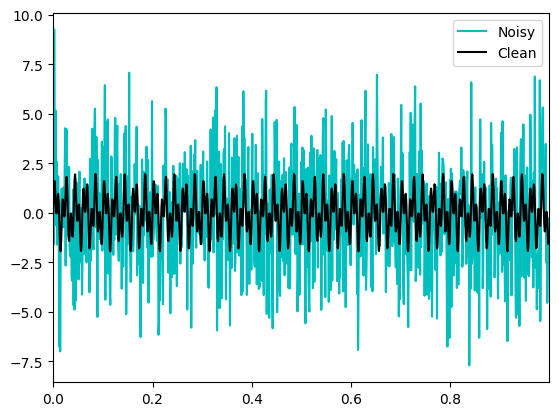

In [ ]:
# # Create a signal with two frequencies
# dt = 0.001  # Time step
# t = np.arange(0, 1, dt)  # Time vector from 0 to 1 second
# f = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t) # Sum of two sine waves

# # Add random white noise
# f_clean = f
# f = f + 2.5*np.random.randn(len(t))

# plt.plot(t, f, color='c', label='Noisy')
# plt.plot(t, f_clean, color='k', label='Clean')
# plt.xlim(t[0], t[-1])
# plt.legend()

/home/jupyter_share/miniconda3/envs/seismo2/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jupyter_share/miniconda3/envs/seismo2/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


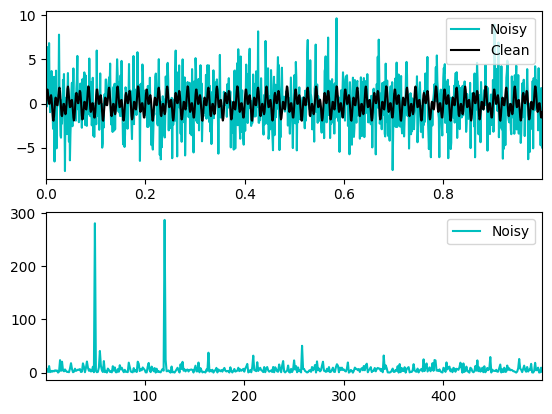

In [ ]:
# n = len(t)
# fhat = np.fft.fft(f, n)  # Compute the FFT
# PSD = fhat * np.conj(fhat) / n  # Power spectral density
# freq = (1/(dt*n)) * np.arange(n)  # Create a vector of frequencies
# L = np.arange(1, np.floor(n/2), dtype='int')  # Only plot the first half of the frequencies

# fig, axs = plt.subplots(2, 1)

# plt.sca(axs[0])
# plt.plot(t, f, color='c', label='Noisy')
# plt.plot(t, f_clean, color='k', label='Clean')
# plt.xlim(t[0], t[-1])
# plt.legend()

# plt.sca(axs[1])
# plt.plot(freq[L], PSD[L], color='c', label='Noisy')
# plt.xlim(freq[L[0]], freq[L[-1]])
# plt.legend()

In [ ]:
# # Use PSD to filter out noise
# indices = PSD > 100
# PSDclean = PSD * indices
# fhat = indices * fhat
# ffilt = np.fft.ifft(fhat)

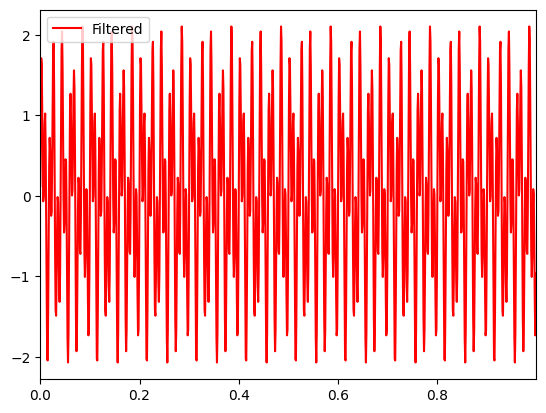

In [ ]:
# plt.plot(t, ffilt.real, color='r', label='Filtered')
# plt.xlim(t[0], t[-1])
# plt.legend()

/home/jupyter_share/miniconda3/envs/seismo2/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jupyter_share/miniconda3/envs/seismo2/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


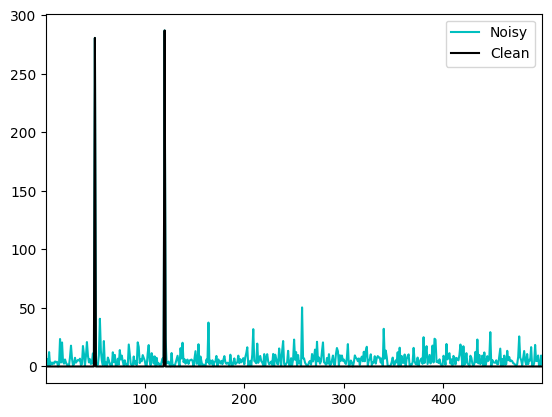

In [ ]:
# plt.plot(freq[L], PSD[L], color='c', label='Noisy')
# plt.plot(freq[L], PSDclean[L], color='k', label='Clean')
# plt.xlim(freq[L[0]], freq[L[-1]])
# plt.legend()
# plt.show()

Trying similar denoising on DAS (earthquake data)

In [ ]:
# file_path = os.path.join("raw_data", "KKFLS.h5")

# # Load the data
# f = h5py.File(file_path, 'r')

# # Get dimensions of data
# data = f['Acquisition/Raw[0]/RawData'][:] # numpy array
# data_time = f['Acquisition/Raw[0]/RawDataTime'][:]
# data_sample_count = f['Acquisition/Raw[0]/RawDataSampleCount'][:]

# print(f"Data shape: {data.shape}")
# print(f"DataTime shape: {data_time.shape}")
# print(f"DataSampleCount shape: {data_sample_count.shape}")

Data shape: (3000, 8531)
DataTime shape: (3000,)
DataSampleCount shape: (3000,)


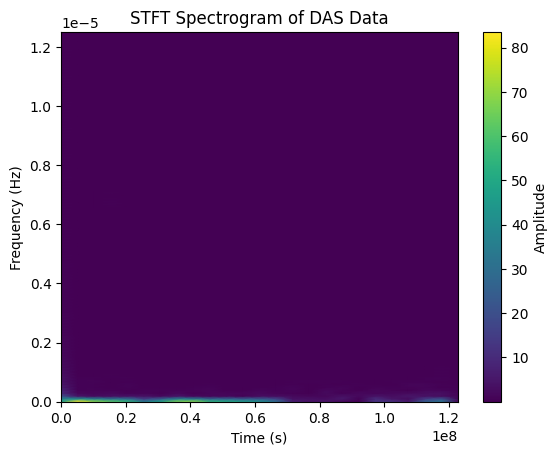

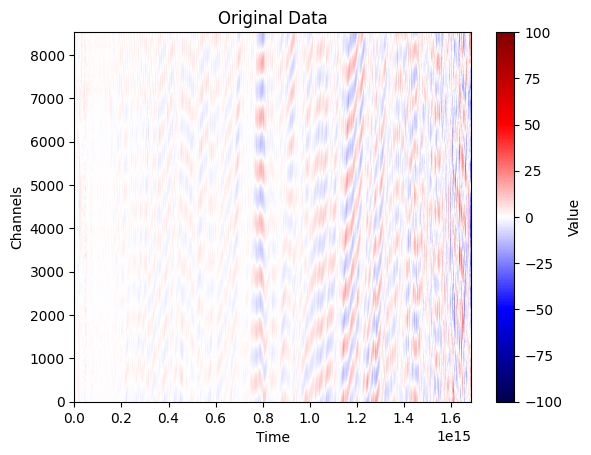

In [ ]:
# # Transpose the data to (channels, samples)
# data_transposed = data.T

# channel_number = 0

# # Choose a single channel to perform STFT (e.g., channel 0)
# channel_data = data_transposed[channel_number, :]

# # Parameters for STFT
# fs = 1 / (data_time[1] - data_time[0])  # Sampling frequency from the time vector.
# nperseg = 256
# noverlap = nperseg // 2

# # Perform STFT
# frequencies, times, Zxx = signal.stft(channel_data, fs, nperseg=nperseg, noverlap=noverlap)

# # Plot the spectrogram
# plt.pcolormesh(times, frequencies, np.abs(Zxx), shading='gouraud')
# plt.colorbar(label='Amplitude')
# plt.ylabel('Frequency (Hz)')
# plt.xlabel('Time (s)')
# plt.title('STFT Spectrogram of DAS Data')
# plt.show()

# # Plot the image as you were originally doing.
# plt.imshow(data, aspect='auto', cmap='seismic', vmin=-1e2, vmax=1e2, extent=[0, data_time[-1], 0, data.shape[1]])

# plt.xlabel("Time")
# plt.ylabel("Channels")
# plt.title("Original Data")
# plt.colorbar(label = "Value")
# plt.show()

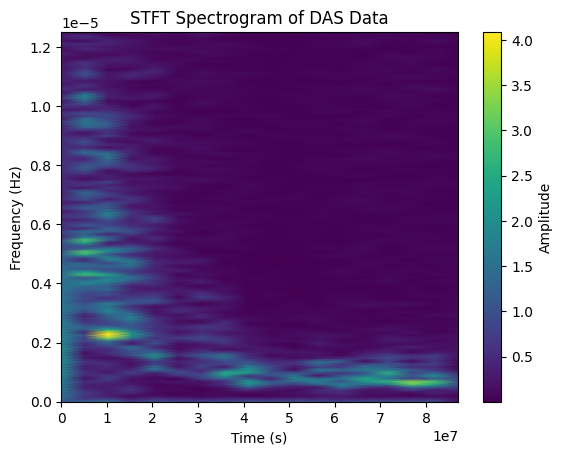

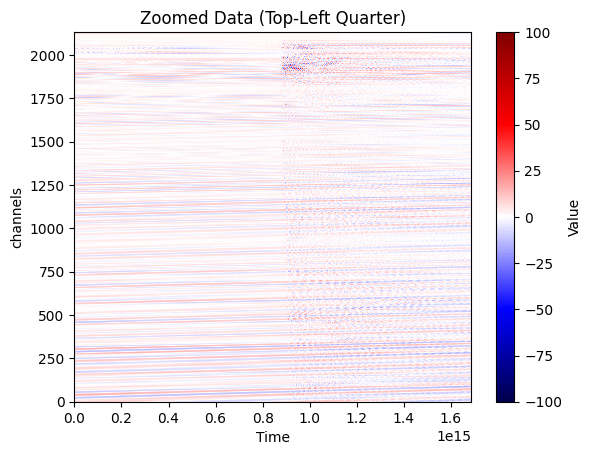

In [ ]:
# # Trying to zoom into the bottom-left corner of the data
# # Calculate midpoints
# time_midpoint = len(data_time) // 4
# channel_midpoint = data.shape[1] // 4

# # Slice the data (top-left quarter)
# zoomed_data = data[:time_midpoint, :channel_midpoint]
# zoomed_time = data_time[:time_midpoint]

# channel_number = 0

# # Choose a single channel to perform STFT (e.g., channel 0)
# channel_data = zoomed_data[channel_number, :]

# # Parameters for STFT
# fs = 1 / (zoomed_time[1] - zoomed_time[0])  # Sampling frequency from the time vector.
# nperseg = 256
# noverlap = nperseg // 2

# # Perform STFT
# frequencies, times, Zxx = signal.stft(channel_data, fs, nperseg=nperseg, noverlap=noverlap)

# # Plot the spectrogram
# plt.pcolormesh(times, frequencies, np.abs(Zxx), shading='gouraud')
# plt.colorbar(label='Amplitude')
# plt.ylabel('Frequency (Hz)')
# plt.xlabel('Time (s)')
# plt.title('STFT Spectrogram of DAS Data')
# plt.show()


# # Plot the zoomed data
# plt.imshow(zoomed_data.T, aspect='auto', cmap='seismic', vmin=-1e2, vmax=1e2, extent=[0, zoomed_time[-1], 0, channel_midpoint])

# plt.xlabel("Time")
# plt.ylabel("channels")
# plt.title("Zoomed Data (Top-Left Quarter)")
# plt.colorbar(label="Value")
# plt.show()


In [ ]:
# # Trying to filter out noise using FFT
# dt = 1/fs
# # t = np.arange(0, zoomed_time, dt)
# t = zoomed_time
# f = channel_data.copy()
# n = len(zoomed_time)
# fhat = np.fft.fft(f, n)  # Compute the FFT
# PSD = fhat * np.conj(fhat) / n  # Power spectral density
# freq = (1/(dt*n)) * np.arange(n)  # Create a vector of frequencies
# L = np.arange(1, np.floor(n/2), dtype='int')  # Only plot the first half of the frequencies

# print(t.shape)
# print(f.shape)
# print()

# # plt.figure(figsize=(12, 6))
# # plt.plot(t, f, color='k', label='Original')
# # plt.xlim(t[0], t[-1])
# # plt.xlabel("Time (s)")
# # plt.ylabel("Amplitude")
# # plt.legend()
# # plt.title(f"Channel {channel_number} (Zoomed)")
# # plt.show()

(750,)
(2132,)
2.5e-05
